# 2017 ATP Season


### Introduction

Today we will be looking at the data for the 2017 Association of Tennis Professionals season. The data contained in this notebook will look at the matches played on the men's professional tennis tour. We will analyze the match performances at this level as well as attributes that contribute to winning. The goal of this is to gain some insight into what contributes to success on the tour.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re

In [2]:
df = pd.read_csv('match_scores_2017_unindexed_csv.csv')

# Data Cleaning

In order to start our analysis, we need to clean the data. We will be getting rid of unecessary columns that will not be needed for the analysis.

In [3]:
df.drop(['tourney_url_suffix','tourney_year_id','winner_slug',
        'loser_slug','match_stats_url_suffix'],axis=1,inplace=True)

For the purpose of our analysis, we only want to look at main draw matches. That means any tournament round that took place in qualifying, we will want to remove. 

In [4]:
qualifying=df['tourney_round_name'].str.contains('Qualifying')
qualifying_rounds=df[qualifying]
df=df[~qualifying]

Next we need to check if we have any null values that arent in the winner and loser seed columns. These two columns will have nulls since very player in a tournament isnt seeded.

In [5]:
pd.isnull(df).sum()

tourney_order               0
tourney_slug                0
tourney_round_name          0
round_order                 0
match_order                 0
winner_name                 0
winner_player_id            0
loser_name                  0
loser_player_id             0
winner_seed               991
loser_seed               1251
match_score_tiebreaks       0
winner_sets_won             0
loser_sets_won              0
winner_games_won            0
loser_games_won             0
winner_tiebreaks_won        0
loser_tiebreaks_won         0
match_id                    0
dtype: int64

Next we will be adding player attribute data, which includes country, weight, height, technique

In [6]:
pdf = pd.read_csv('player_overviews_unindexed_csv.csv')

In our player dataset, we have alot of players before 2017 where the attributes are missing. Since we are only concerned about players in the 2017 season, we only want those in our data. In addition, we will remove unnecessary columns.

In [7]:
pd.isnull(pdf).sum()

player_id           0
player_slug         0
first_name          0
last_name           0
player_url          0
flag_code        2185
residence        8898
birthplace       7874
birthdate        5798
birth_year       5798
birth_month      5798
birth_day        5798
turned_pro       9379
weight_lbs       8206
weight_kg        8206
height_ft        8254
height_inches    8254
height_cm        8254
handedness       9776
backhand         9776
dtype: int64

In [8]:
pdf.dropna(inplace=True)

# This drops all the players from the dataset before the year 2017 due to a lack of attribute data

In [9]:
pdf.drop(['player_slug','first_name','last_name','player_url',
          'birth_month','birth_day'],axis=1,inplace=True)

Now that we have cleaned the data for the player attributes, we will perform a join. We will be using this merged data set for the final part of the notebook.

In [10]:
tdf=pd.merge(df,pdf,how='left',left_on='winner_player_id'
             ,right_on='player_id')


In [11]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2633 entries, 0 to 2632
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tourney_order          2633 non-null   int64  
 1   tourney_slug           2633 non-null   object 
 2   tourney_round_name     2633 non-null   object 
 3   round_order            2633 non-null   int64  
 4   match_order            2633 non-null   int64  
 5   winner_name            2633 non-null   object 
 6   winner_player_id       2633 non-null   object 
 7   loser_name             2633 non-null   object 
 8   loser_player_id        2633 non-null   object 
 9   winner_seed            1642 non-null   object 
 10  loser_seed             1382 non-null   object 
 11  match_score_tiebreaks  2633 non-null   object 
 12  winner_sets_won        2633 non-null   int64  
 13  loser_sets_won         2633 non-null   int64  
 14  winner_games_won       2633 non-null   int64  
 15  lose

# Grandslams

Now we begin analysis, we will be looking at our match data and analyzing match performance.

In tennis we have grand slams tournaments that are best of 5 sets and the rest of the tournaments are best of 3 sets. We will want to add a column to our database denoting the types of tournaments. The 4 grandslams are Australian Open, Roland Garros, Wimbledon, and US Open.

In [12]:
grand_slams=['australian-open','roland-garros','wimbledon','us-open']
df['match_type'] = ['5 sets' if x in grand_slams else '3 sets' for x in df['tourney_slug']]

# We are creating a column to determine if the tournament is a grandslam or an ATP tournament. 
# Grandslams are played best of 5 sets while ATP matches plays best of 3. 

Since grandslams are the biggest tournaments, we want to analyze which players performed the best at this stage. Let's look at the players who won the most matches at this level in the 2017 season and determine the level of competitiveness when it comes to winning these titles. Since grandslams are extremely competitive, I believe we will find that very few players are winning many matches at this level.

In [13]:
# Create dataset of grandslam matches only
five_sets=df['match_type'].str.contains('5 sets') 
gs_df=df[five_sets]
# Find the players who won the most matches
gs2 = gs_df.groupby(['winner_name'])['winner_player_id'].count() 
gs3=gs2.sort_values(ascending=False)
#select only players who won more than 10 matches
ten_wins=gs3>=10 
gs_ten=gs3[ten_wins]
print(gs_ten)

winner_name
Rafael Nadal             23
Roger Federer            18
Dominic Thiem            14
Marin Cilic              13
Kevin Anderson           12
Andy Murray              12
Grigor Dimitrov          11
Roberto Bautista Agut    11
Milos Raonic             11
Sam Querrey              11
Stan Wawrinka            11
Pablo Carreno Busta      11
Gael Monfils             10
Name: winner_player_id, dtype: int64


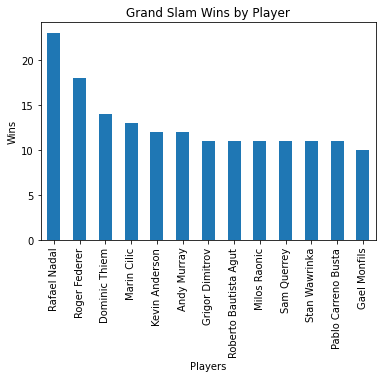

In [14]:
gs_ten.plot.bar(rot=15, title="Grand Slam Wins by Player")
plt.xlabel('Players')
plt.ylabel('Wins')
plt.xticks(rotation = 90)

plt.show()

As we look at the chart, we see there is a large disparity from the top two players and the remaining players. Note that this is a group of players with 10 or more wins. There are several other players with less wins or even no wins. The bars decrease in an exponential fashion, indicating that there are a couple dominant players who get the most wins at these tournaments. This chart also plots a long tail of participants, indicating that the majority of players had lower success rates, with a gradual decrease in the number of matches won.

Now lets investigate what percentile these players exist in. Lets define a function that finds what percentage of players that competed in a grandslam won over 10 matches given the gs_df data frame.

Note: This isn't as simple as finding the length of the winners because there are many players who did not win a match

In [15]:
def ten_win_percentage(df):
    winners = gs_df.groupby(['winner_name'])['winner_player_id'].count()
    winners_dict=winners.to_dict()
    #determine all the players who won at least one match
    winners_set=set(winners_dict.keys()) 
    losers = gs_df.groupby(['loser_name'])['loser_player_id'].count()
    losers_dict=losers.to_dict()
    losers_set=set(losers_dict.keys()) 
    # determine all the players who didnt win a single match
    only_losers=losers_set.difference(winners_set) 
    # add the length of both sets to determine the number of competitors
    total_players=len(winners)+len(only_losers) 
    #determine number of players with more than 10 wins
    ten_win_club=len(winners[winners>=10]) 
    # computes the percentage
    percentage=round((ten_win_club/total_players)*100,2) 
    return f"{percentage}%"

ten_win_percentage(gs_df)

'6.74%'

The amount of players winning more than 10 matches reveals alot of information about grandslam competitiveness. This is an elite group of individuals since winning at this level must be extremely challenging. With a vast majority of players winning under 10 matches, it shows many of them achieve modest results at these tournaments. With that I believe winning more than 10 can be used as a benchmark for excellence as it shows players achieving this feat were high performing atheletes. This could be good for commentators to talk about during these tournaments.

I think future research should focus on multiple years of grandslame performances.This can help identify trends, changes in player performance, and potential shifts in the competitive landscape. This analysis can help us identify which players were the highest performing throughout history. 

# Titles

Now lets examine how players perform in title matches. Lets see which players won the most titles. We will also look at the players who lost in the title matches. This indicates which players perform well in the big moments. In this we are looking to find out how often players are successful in finals. Due to the competitve landscape of tennis, I believe we will see many players with many finals apperances and many of these players will be title holders and runnerups throughout the season. 

In [16]:
#selects all matches that were finals of the tournament
finals=df[df['round_order']==1] 
#find number of titles won by each
titles = finals.groupby(['winner_name'])['winner_player_id'].count()
#find number of titles won by each
runner_up=finals.groupby(['loser_name'])['loser_player_id'].count() 
titles_df=titles.to_frame()
runner_up_df=runner_up.to_frame()


titles_df.reset_index(inplace=True)
runner_up_df.reset_index(inplace=True)

# Now we will  merge the winners and runner ups to show the number of titles(Wins) and runnerups by each player(Losses)
finals_df=pd.merge(titles_df,runner_up_df, 
                   left_on='winner_name', right_on='loser_name', 
                   how='outer')
finals_df=finals_df.rename(columns={'winner_name':'Player',"winner_player_id": "Wins", 
                          "loser_player_id": "Losses"})
finals_df=finals_df.fillna({'Player':finals_df['loser_name'],
                            'Wins':0,'Losses':0})
finals_df=finals_df[['Player','Wins','Losses']]

# As I was working through the data I found a few data cleaning issues.
# I use regex to make sure there is only one space between a players first and last name
finals_df['Player'] = finals_df['Player'].replace(r'\s+', ' ', regex=True)
aggregation_functions = {'Wins': 'sum', 'Losses': 'sum'}

# Now we will aggregate the numbers of Wins and Losses are the finals stage
finals_df = finals_df.groupby(finals_df['Player']).aggregate(aggregation_functions)
finals_df=finals_df.sort_values(by = ['Wins', 'Losses'], 
                                ascending = [False, True]).reset_index()
print(finals_df)

                Player  Wins  Losses
0        Roger Federer   7.0     1.0
1         Rafael Nadal   6.0     4.0
2     Alexander Zverev   5.0     1.0
3      Grigor Dimitrov   4.0     1.0
4   Jo-Wilfried Tsonga   4.0     1.0
..                 ...   ...     ...
59       Kei Nishikori   0.0     2.0
60      Kevin Anderson   0.0     2.0
61        Milos Raonic   0.0     2.0
62        Nick Kyrgios   0.0     2.0
63       Paolo Lorenzi   0.0     2.0

[64 rows x 3 columns]


# Multiple Title Winners

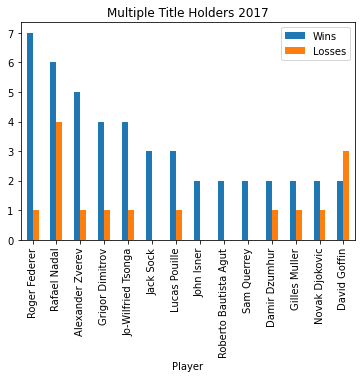

In [17]:
multi_title=finals_df[finals_df['Wins']>1]
multi_title.plot(x="Player", y=["Wins", "Losses"], kind="bar") 
plt.title("Multiple Title Holders 2017")
plt.show()

# One Title Winner

From the graph, we see all these players with more than one title. Its remarkable to see exponential decay in the number of titles as well. It reveals that the sport of tennis is dominated by a few individuals. It also shows that not all these players had more than 10 wins at the grandslam level, showing that performing well on the main tour doesn't always transalte at the grandslam level As predicted, most of these players were champions and runner ups throughout the year. It shows that the players have to be consistent enough to put themselves in finals, but it is very difficult to win 100% of the time in a given year. 

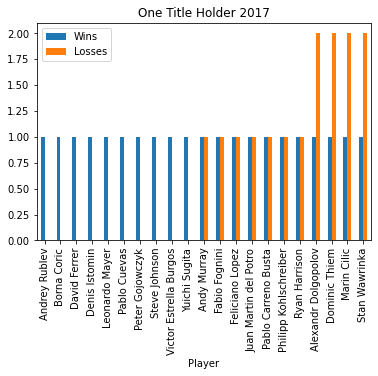

In [18]:
one_title=finals_df[finals_df['Wins']==1]
one_title.plot(x="Player", y=["Wins", "Losses"], kind="bar") 
plt.title("One Title Holder 2017")
plt.show()

In this group, we see about half the players ended up in multiple finals while the other half made a single final and won the trophy. While making multiple finals seems to be important in this group, we see that success can be achieved with few opportunities. It is important to note that only 10 players achieve 100% win less within the single title holders group. There are a total 55 ATP finalists. With 18% of that belonging to this subgroup, it shows that a player aways has a shot at winning even if they only make 1 final in a season. 

# Runner-Ups

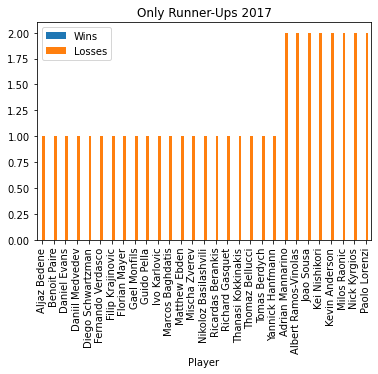

In [19]:
no_title=finals_df[finals_df['Wins']<1]
no_title.plot(x="Player", y=["Wins", "Losses"], kind="bar") 
plt.title("Only Runner-Ups 2017")
plt.show()

In this graph we see that that making multiple finals matters less. Many runner-ups achieved only one final. The percentage of runner-ups making more than one final compared to all ATP finalists is 15%. While this percentage is small, it also goes to show that making multiple finals doesn't always guarantee victory. That means 45% of all finalists were title-holders and runner ups. This disproves my hypothesis that we will see many players in both groups.

For future research, we should look at players win-loss record at finals over many years. This can give us more evidence to see if my findings are true across history and not just in a given year.

In [20]:
print('How many players won multiple titles? ' + str(len(multi_title)))
print('How many players won one title? ' +str(len(one_title)))
print('How many players were runner-ups? '+str(len(no_title)))

How many players won multiple titles? 14
How many players won one title? 21
How many players were runner-ups? 29


# Player Attributes

Finally we are going to analyze country of origin and height to see how those affect player success. The metric for success will be the number of matches won. 

With many tournaments being held in Europe, I believe we will see players from European countries winning a majority of the matches. 

With the best players in the world being tall but not "giants", I believe we will see a higher success rate among this group of players.

In [21]:
tdf=tdf.drop(['loser_name', 'loser_player_id','loser_seed','loser_sets_won','loser_games_won','loser_tiebreaks_won'], axis=1)
# Removing fields pertaining to the loser column as we want to analyze the metrics of the winners of these matches

In [22]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2633 entries, 0 to 2632
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tourney_order          2633 non-null   int64  
 1   tourney_slug           2633 non-null   object 
 2   tourney_round_name     2633 non-null   object 
 3   round_order            2633 non-null   int64  
 4   match_order            2633 non-null   int64  
 5   winner_name            2633 non-null   object 
 6   winner_player_id       2633 non-null   object 
 7   winner_seed            1642 non-null   object 
 8   match_score_tiebreaks  2633 non-null   object 
 9   winner_sets_won        2633 non-null   int64  
 10  winner_games_won       2633 non-null   int64  
 11  winner_tiebreaks_won   2633 non-null   int64  
 12  match_id               2633 non-null   object 
 13  player_id              2615 non-null   object 
 14  flag_code              2615 non-null   object 
 15  resi

Tennis is a sport of national pride. Every match, the player has his country flag next to his name. As the country of representation is important, we will look at which countries have the best performances in the 2017 season. Since we have several countries represented on tour, we will narrow our analysis to countries with 5 or more match wins in the 2017 season. We will be using this function to plot a pie chart to compare winning percentages by country.

In [23]:
def five_players(df):
    countries=tdf[['flag_code', 'winner_name']]
    # We will have many entries with the same record because many players won more than one match
    players=countries.drop_duplicates() 
    # Counts the number of wins for each country
    country_player=players.groupby(['flag_code'])['winner_name'].count() 
    country_player=country_player.to_frame()
    country_player=country_player.rename(columns={'winner_name':'count'})
    #Retrieves countries with more than 5 match wins
    five_players=country_player[country_player['count']>=5].reset_index() 
    five_list=five_players['flag_code'].tolist()
    return five_list

five_players(tdf)

['ARG',
 'AUS',
 'AUT',
 'BEL',
 'CAN',
 'CZE',
 'ESP',
 'FRA',
 'GBR',
 'GER',
 'ITA',
 'JPN',
 'RUS',
 'SRB',
 'USA']

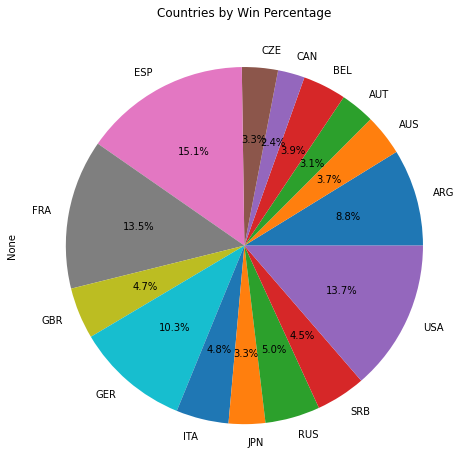

In [24]:
five_c=five_players(tdf)
countries= tdf[tdf['flag_code'].isin(five_c)]
countries=countries.groupby(['flag_code']).size()
win_percentage=countries.plot.pie(figsize=(8,48),autopct='%.1f%%')
win_percentage.set_title('Countries by Win Percentage')
plt.show()

My original hypothesis holds true that European countries do see a majority of the success. I want to highlight the USA and Argentina for being top 5 countries in match wins amongst all 15 countries in the group. With both countries consuming 22.5% of all match wins on the tour amongst the 15 countries, this shows that success is achievable outside of Europe. 

Future studies can explore the correlation between economic factors and tennis success. We can investigate whether countries with higher economic development tend to produce more successful tennis players, considering factors such as access to resources, training facilities, and coaching expertise.

Now we will group all ATP match winners based on height. We will look at the distribution of number of match wins based on height. We will classify height as short(under 6'0"), tall(6'0"-6'5"), giant(6'6" and over)

In [25]:
# Partition the groups based on height in inches
short = tdf.loc[tdf['height_inches']<72,['winner_name','height_inches']]
tall = tdf.loc[(tdf['height_inches']>=72)& (tdf['height_inches']< 78),['winner_name','height_inches']]
giants= tdf.loc[(tdf['height_inches']>=78),['winner_name','height_inches']]

# We find the total number of wins for each player within their respective groups
short=short.groupby(['winner_name']).size()
tall=tall.groupby(['winner_name']).size()
giants=giants.groupby(['winner_name']).size()


count    41.000000
mean     12.414634
std      12.961434
min       1.000000
25%       2.000000
50%       8.000000
75%      20.000000
max      50.000000
dtype: float64

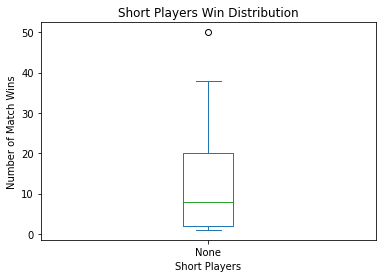

In [26]:
short_box=short.plot.box()
short_box.set_title('Short Players Win Distribution')
short_box.set_xlabel('Short Players')
short_box.set_ylabel('Number of Match Wins')
short.describe()



For short players we see the middle 50th percentile to be in between 2 and 20 wins. We do not have a normal distribution as many of the short players fall below the 50th percentile.

count    150.000000
mean      11.806667
std       12.453779
min        1.000000
25%        2.000000
50%        7.000000
75%       18.750000
max       67.000000
dtype: float64

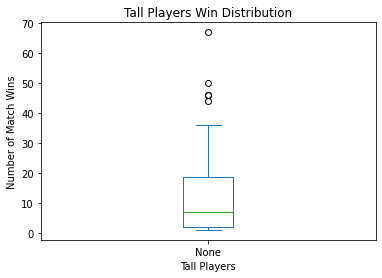

In [27]:
tall_box=tall.plot.box()
tall_box.set_title('Tall Players Win Distribution')
tall_box.set_xlabel('Tall Players')
tall_box.set_ylabel('Number of Match Wins')
tall.describe()

For tall players, we see a similar distribution to shorter players. The distribution follows a similar shape, but we see far more outliers. This disproves my initial hypothesis that tall players on average will perform better. The outliers indicate the best players in the world, which led me to believe the distribution would favor them as advantageous to short and giant players. 

count    15.000000
mean     22.333333
std      16.905902
min       1.000000
25%       5.500000
50%      22.000000
75%      35.500000
max      53.000000
dtype: float64

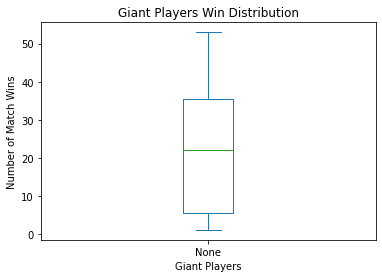

In [28]:
giant_box=giants.plot.box()
giant_box.set_title('Giant Players Win Distribution')
giant_box.set_xlabel('Giant Players')
giant_box.set_ylabel('Number of Match Wins')
giants.describe()

The giants list only contains 15 players, which is smaller than the other two lists. Given the data, we do see a very different distribution. The middle 50th percentile is a larger range and the 50th and 75th percentile values are higher than the other two groups. While many athletes don't grow to these heights, those that do perform better than their shorter counterparts

My analysis found that height provides an advantage to atheletes. While tall athletes consist of the majority of the competition and those atheletes are capable of winning many matches in the season, the giant atheletes show better results on average.

Some future analysis can look into the giants group. We can analyze what aspects of their game such as their serve lead to them achieving higher results